<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 5 · Lunes — Introducción a Machine Learning</h1>
<h3>Estandarización + División Train/Test</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · jesus.jeduardo7@gmail.com<br/><br/>
    <b>SkillNest · b2b-sonda-data-science</b>
</div>
<br/>

> 📚 **Fuente:** *Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow* (Aurélien Géron, 3ª ed.)

## 🎯 Objetivos de hoy

Al final de la clase vas a poder:

1. Explicar qué es **Machine Learning** y cuándo conviene usarlo.
2. Reconocer los **tipos de aprendizaje** (supervisado, no supervisado, por refuerzo).
3. Conocer **Scikit-Learn** y su patrón `.fit()` / `.transform()` / `.predict()`.
4. **Estandarizar** columnas numéricas para que estén en la misma escala.
5. **Dividir** un dataset en **training y test** correctamente.
6. Resolver **5 ejercicios prácticos** que veremos en vivo.

> Hoy NO vemos: encoding de categóricas, pipelines ni modelos completos — eso viene los días siguientes.

# 1. ¿Qué es Machine Learning?

**Machine Learning (ML)** es el conjunto de técnicas a través de los cuales un computador puede **aprender de los datos** sin que le programemos reglas explícitas para cada caso.

### 🧠 Una analogía simple

Imagina que quieres enseñarle a alguien a distinguir un correo legítimo de un correo spam.

- **Sin ML:** le explicas reglas — *"si contiene la palabra GANASTE en mayúsculas, es spam"*, *"si viene de un dominio raro, es spam"*, etc. El problema: cada día aparecen formas nuevas de spam y tendrás que actualizar las reglas para siempre.
- **Con ML:** le muestras 10.000 correos ya clasificados (esto es spam, esto no es spam) y dejas que **aprenda los patrones por sí solo**. Cuando aparezca un correo nuevo, el modelo te dirá si es spam basándose en lo que ya vio.

**Datos + algoritmo → modelo que predice.** Esa es la idea central.

# 2. Tipos de aprendizaje

| Tipo | ¿Qué significa? | Ejemplo real |
|---|---|---|
| 🎯 **Supervisado** | Aprende con pares `(entrada, respuesta correcta)` | Predecir precio de una casa con precios históricos |
| 🔍 **No supervisado** | Solo entradas, sin respuesta. Busca patrones | Agrupar clientes en segmentos |
| 🧩 **Semi supervisado** | Algunos datos tienen respuesta, otros no | Clasificar fotos con pocas etiquetas |
| 🎮 **Por refuerzo** | Aprende probando y recibiendo recompensas | Un agente que aprende ajedrez |

> 💡 En este bootcamp nos enfocamos en **aprendizaje supervisado** (es el más común en proyectos reales).

# 3. Scikit-Learn — la herramienta

<img src="images/ml-libraries/scikit-learn-logo-notext.png" alt="" width="180px" align="center"/>

Scikit-Learn es la biblioteca estándar de ML en Python. Su gran fortaleza es la **consistencia**: todos sus objetos siguen los mismos 3 patrones.

| Patrón | Método | ¿Qué hace? | Analogía |
|---|---|---|---|
| **Estimador** | `.fit(X)` | Aprende de los datos | Un alumno estudia el material |
| **Transformador** | `.transform(X)` | Aplica lo aprendido para modificar datos | El alumno usa lo aprendido |
| **Predictor** | `.predict(X)` | Genera predicciones | El alumno responde una pregunta nueva |

### 🪄 La regla mágica de 2 pasos

```python
modelo.fit(X_train)           # 1) aprende
y_pred = modelo.predict(X_test)   # 2) predice
```

Casi todo en ML pasa por estos dos métodos. La belleza es que **cambias el algoritmo y el código sigue siendo idéntico**.

### ¿Cómo se instala?

```bash
pip install scikit-learn
```

# 4. Estandarización — ¿por qué y cómo?

### ¿Por qué estandarizar?

Imagina un dataset con dos columnas: `edad` (rango 0–100) y `salario` (rango 200.000 a 5.000.000).

Si entrenas un modelo sin escalar, la columna `salario` **dominará** el aprendizaje solo por tener números más grandes — no porque sea más importante. El modelo se confunde.

**El escalamiento pone todas las variables en una escala comparable.**

### Tipos comunes

| Tipo | Qué hace | Cuándo usarlo |
|---|---|---|
| 📏 **Normalización (Min-Max)** | Lleva valores a `[0, 1]` | Cuando los datos NO siguen normal |
| 📊 **Estandarización (Standard)** | Media = 0, desv. estándar = 1 | Es el default — sirve para casi todo |

> 💡 **Regla simple:** usa `StandardScaler` por defecto.

### 👀 Demo en vivo — Estandarizar una columna

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Cargamos el dataset de casas de California
df = pd.read_csv('data/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
X=df.drop('ocean_proximity', axis=1)
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
X.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [22]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [25]:
scaler = MinMaxScaler()
scaler.fit(X)
X_scaled=scaler.transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)
X_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638
...,...,...,...,...,...,...,...,...,...
20635,0.324701,0.737513,0.470588,0.042296,0.057883,0.023599,0.054103,0.073130,0.130105
20636,0.312749,0.738576,0.333333,0.017676,0.023122,0.009894,0.018582,0.141853,0.128043
20637,0.311753,0.732200,0.313725,0.057277,0.075109,0.028140,0.071041,0.082764,0.159383
20638,0.301793,0.732200,0.333333,0.047256,0.063315,0.020684,0.057227,0.094295,0.143713


In [26]:
X_scaled.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,0.476125,0.328572,0.541951,0.066986,0.083313,0.039869,0.081983,0.232464,0.395579
std,0.199555,0.226988,0.246776,0.055486,0.065392,0.031740,0.062873,0.131020,0.237928
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.253984,0.147715,0.333333,0.036771,0.045779,0.021974,0.045881,0.142308,0.215671
50%,0.583665,0.182784,0.549020,0.054046,0.067349,0.032596,0.067094,0.209301,0.339588
75%,0.631474,0.549416,0.705882,0.080014,0.100248,0.048264,0.099326,0.292641,0.514897
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Vamos a estandarizar 'median_house_value'
scaler = StandardScaler()

# Paso 1: fit → el scaler APRENDE la media y la desv. estándar
scaler.fit(df[['median_house_value']])

print(f'Media aprendida:     {scaler.mean_[0]:,.2f}')
print(f'Desv. estándar:      {scaler.scale_[0]:,.2f}')

# Paso 2: transform → aplica lo aprendido
precio_escalado = scaler.transform(df[['median_house_value']])

print(f'\nDespués de estandarizar:')
print(f'  Media:  {precio_escalado.mean():.4f}  (debe ser ≈ 0)')
print(f'  Desv:   {precio_escalado.std():.4f}  (debe ser ≈ 1)')

Media aprendida:     206,855.82
Desv. estándar:      115,392.82

Después de estandarizar:
  Media:  -0.0000  (debe ser ≈ 0)
  Desv:   1.0000  (debe ser ≈ 1)


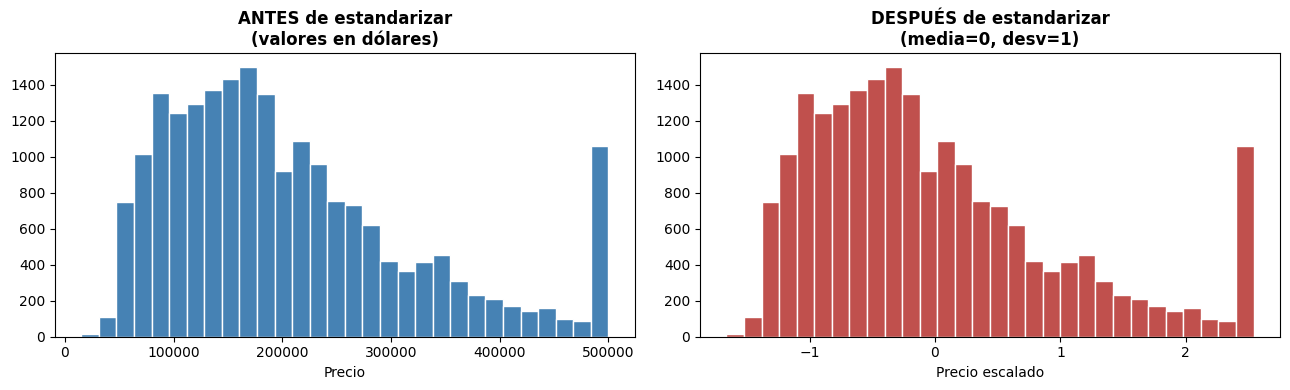

👉 Misma forma de distribución, distinta escala. Eso es lo que queremos.


In [8]:
# Comparamos visualmente antes y después
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['median_house_value'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('ANTES de estandarizar\n(valores en dólares)', fontweight='bold')
axes[0].set_xlabel('Precio')

axes[1].hist(precio_escalado, bins=30, color='#C0504D', edgecolor='white')
axes[1].set_title('DESPUÉS de estandarizar\n(media=0, desv=1)', fontweight='bold')
axes[1].set_xlabel('Precio escalado')

plt.tight_layout()
plt.show()

print('👉 Misma forma de distribución, distinta escala. Eso es lo que queremos.')

# 5. División en Training y Test

### 📚 La analogía del examen

Imagina que estudias para una prueba con un libro de 100 ejercicios resueltos.

- Si **memorizas las 100 respuestas exactas**, te va muy bien en esos 100 — pero el día del examen te ponen 10 ejercicios **nuevos** y fallas.
- Si **aprendes el método**, puedes resolver cualquier ejercicio nuevo.

Lo mismo pasa con ML: queremos un modelo que **generalice**, no que solo memorice.

### División clásica

| Conjunto | ¿Para qué? | Tamaño típico |
|---|---|---|
| 🏋️ **Training set** | Para que el modelo aprenda los patrones | 70-80% |
| 🎯 **Test set** | Para evaluar generalización con datos NUNCA vistos | 20-30% |

> ⚠️ **Regla de oro:** el test set **NUNCA** debe tocarse durante el entrenamiento. Si lo usas para tunear el modelo, ya no estás midiendo generalización honesta.

### 👀 Demo en vivo — `train_test_split`

In [28]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [38]:
from sklearn.model_selection import train_test_split

# Cargamos el dataset
df = pd.read_csv('data/housing.csv')

# Separamos en features (X) y target (y)
# X = todo lo que el modelo USA para predecir
# y = lo que QUEREMOS predecir
X = df.drop(columns=['median_house_value', 'ocean_proximity'])  # ocean_proximity es categórica, la dejamos fuera por hoy
y = df['median_house_value']

print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')

Shape de X: (20640, 8)
Shape de y: (20640,)


In [39]:
# train_test_split divide en 4 piezas: X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)

print(f'Tamaño total:        {len(X):,} filas')
print(f'Training (X_train):  {len(X_train):,} filas  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test     (X_test):   {len(X_test):,} filas  ({len(X_test)/len(X)*100:.0f}%)')

Tamaño total:        20,640 filas
Training (X_train):  14,448 filas  (70%)
Test     (X_test):   6,192 filas  (30%)


In [40]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
7061,-118.02,33.93,35.0,2400.0,398.0,1218.0,408.0,4.1312
14689,-117.09,32.79,20.0,2183.0,534.0,999.0,496.0,2.8631
17323,-120.14,34.59,24.0,1601.0,282.0,731.0,285.0,4.2026
10056,-121.00,39.26,14.0,810.0,151.0,302.0,138.0,3.1094
15750,-122.45,37.77,52.0,3188.0,708.0,1526.0,664.0,3.3068


In [41]:
y_train.head()

7061     193800.0
14689    169700.0
17323    259800.0
10056    136100.0
15750    500001.0
Name: median_house_value, dtype: float64

In [36]:
X_train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,-119.584102,35.650669,28.575374,2644.939230,539.828281,1427.927326,501.070598,3.876892
std,2.002930,2.135742,12.613634,2163.054433,419.786747,1140.225190,382.221220,1.904908
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.940000,18.000000,1456.750000,296.000000,791.000000,280.000000,2.567225
50%,-118.510000,34.270000,29.000000,2131.000000,437.000000,1168.000000,411.000000,3.539100
75%,-118.010000,37.720000,37.000000,3169.250000,648.000000,1727.000000,607.000000,4.758075
max,-114.310000,41.950000,52.000000,32627.000000,6445.000000,35682.000000,6082.000000,15.000100


In [42]:
X_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250


In [43]:
y_test.head()

20046     47700.0
3024      45800.0
15663    500001.0
20484    218600.0
9814     278000.0
Name: median_house_value, dtype: float64

In [35]:
X_test.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,6192.000000,6192.000000,6192.000000,6192.000000,5985.000000,6192.000000,6192.000000,6192.000000
mean,-119.536109,35.587976,28.789083,2614.352067,533.144528,1419.758721,495.967539,3.856156
std,2.004694,2.135971,12.519541,2224.351073,425.216838,1114.208253,382.589931,1.887973
min,-124.250000,32.540000,1.000000,6.000000,2.000000,8.000000,2.000000,0.499900
25%,-121.770000,33.920000,18.000000,1431.000000,295.000000,778.000000,278.000000,2.552000
50%,-118.470000,34.230000,29.000000,2115.500000,429.000000,1161.000000,406.000000,3.525000
75%,-117.990000,37.700000,37.000000,3094.250000,640.000000,1717.000000,597.250000,4.722200
max,-114.580000,41.860000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100


## Vamos a suponer que yo analice todas las columnas y todas son normales. Eso quiere decir que aplica el standardscaler.

In [ ]:
fit_transform

In [ ]:
scaler= StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [51]:
X_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250


In [52]:
X_test_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.286641,0.191664,-0.283463,-0.527023,NaN,-0.031510,-0.371710,-1.152689
1,0.061963,-0.239115,0.112947,0.137801,NaN,0.120220,0.216975,-0.706406
2,-1.425909,1.006397,1.857152,0.547883,NaN,-0.103428,1.208581,-0.208307
3,0.431434,-0.641799,-0.917719,0.187732,NaN,0.243007,-0.015883,0.976831
4,-1.171273,0.453877,0.430075,-0.135896,NaN,-0.320060,-0.191180,-0.079740


In [53]:
X_test_scaled.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,6192.000000,6192.000000,6192.000000,6192.000000,5985.000000,6192.000000,6192.000000,6192.000000
mean,0.023962,-0.029355,0.016943,-0.014141,-0.015922,-0.007164,-0.013352,-0.010885
std,1.000915,1.000142,0.992575,1.028374,1.012970,0.977216,1.000999,0.991144
min,-2.329616,-1.456532,-2.186232,-1.220048,-1.281238,-1.245347,-1.305757,-1.772846
25%,-1.091388,-0.810364,-0.838437,-0.561235,-0.583241,-0.570019,-0.583637,-0.695539
50%,0.556255,-0.665211,0.033665,-0.244773,-0.264020,-0.234109,-0.248740,-0.184735
75%,0.795913,0.959574,0.667922,0.207728,0.238634,0.253531,0.251642,0.443768
max,2.498477,2.907442,1.857152,16.955805,13.507735,13.047938,12.707556,5.839437


### ⚠️ Atención — orden importante

Cuando combinas **estandarización + train/test split**, hay UNA forma correcta y UNA INCORRECTA:

| ❌ MAL | ✅ BIEN |
|---|---|
| Estandarizar TODO el dataset, después dividir | Dividir PRIMERO, después `fit` con train, luego `transform` test |

**¿Por qué?** Si estandarizas antes, el scaler aprende información del test (media/desv. del test entra en el cálculo) → **filtración de datos** (data leakage).

El orden correcto es:

```python
X_train, X_test, y_train, y_test = train_test_split(...)
scaler = StandardScaler()
scaler.fit(X_train)                    # ← APRENDE solo con train
X_train_esc = scaler.transform(X_train)
X_test_esc  = scaler.transform(X_test) # ← APLICA lo aprendido al test
```

---
# 🏋️ Ejercicios prácticos

Vamos a resolver 5 ejercicios en vivo. **Datasets disponibles:**

- `data/housing.csv` — precios de casas en California (lo usaremos hoy)
- `data/life_expectancy.csv` — esperanza de vida por país

> Para cada ejercicio: intenten resolverlo primero, después lo revisamos juntos.

## Ejercicio 1 — Estandarizar una columna y verificar

**Tarea:**
1. Cargar `data/housing.csv`.
2. Estandarizar la columna `housing_median_age`.
3. Verificar que la media después de estandarizar sea ≈ 0 y la desviación estándar sea ≈ 1.
4. Hacer un histograma antes y después.

Media:  0.0000
Desv:   1.0000


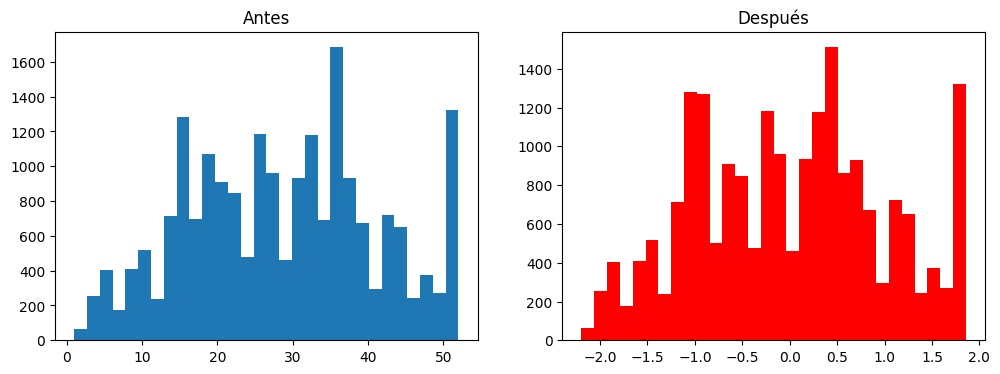

In [37]:
# Tu código aquí 👇
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/housing.csv')
scaler = StandardScaler()
edad_esc = scaler.fit_transform(df[['housing_median_age']])

print(f'Media:  {edad_esc.mean():.4f}')
print(f'Desv:   {edad_esc.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['housing_median_age'], bins=30); axes[0].set_title('Antes')
axes[1].hist(edad_esc, bins=30, color='red'); axes[1].set_title('Después')
plt.show()


<details><summary>💡 Solución</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/housing.csv')
scaler = StandardScaler()
edad_esc = scaler.fit_transform(df[['housing_median_age']])

print(f'Media:  {edad_esc.mean():.4f}')
print(f'Desv:   {edad_esc.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['housing_median_age'], bins=30); axes[0].set_title('Antes')
axes[1].hist(edad_esc, bins=30, color='red'); axes[1].set_title('Después')
plt.show()
```
</details>

## Ejercicio 2 — Estandarizar TODAS las columnas numéricas

**Tarea:**
1. Cargar `data/housing.csv`.
2. Quitar la columna `ocean_proximity` (es categórica, hoy no la tocamos).
3. Estandarizar TODAS las columnas restantes con un solo `StandardScaler`.
4. Convertir el resultado de nuevo a un `DataFrame` con los mismos nombres de columnas y mostrar `.describe()`.

**Pista:** `StandardScaler` puede aprender de varias columnas a la vez si le pasas un DataFrame.

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity'])
scaler = StandardScaler()
df_esc = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_esc.describe().round(3)  # media ≈ 0, std ≈ 1 en todas
```
</details>

## Ejercicio 3 — Dividir en train/test correctamente

**Tarea:**
1. Cargar `data/housing.csv` y quitar `ocean_proximity`.
2. Definir `y = median_house_value` y `X = el resto`.
3. Hacer `train_test_split` con `test_size=0.25` y `random_state=0`.
4. Imprimir el shape de `X_train`, `X_test`, `y_train`, `y_test`.
5. Verificar que `len(X_train) + len(X_test) == len(X)`.

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity'])
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
print(f'Suma OK: {len(X_train) + len(X_test) == len(X)}')
```
</details>

## Ejercicio 4 — Flujo correcto: split PRIMERO, escalar DESPUÉS

**Tarea:** Implementar el flujo correcto (sin data leakage):

1. Cargar y limpiar como antes.
2. `train_test_split` con `test_size=0.2, random_state=42`.
3. **Solo con `X_train`**, hacer `scaler.fit()`.
4. Aplicar `transform` a `X_train` Y `X_test`.
5. Imprimir las medias de `X_train_esc` y de `X_test_esc`. ¿Son iguales? ¿Por qué no?

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity'])
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)                       # APRENDE solo con train
X_train_esc = scaler.transform(X_train)   # aplica
X_test_esc  = scaler.transform(X_test)    # aplica con los MISMOS parámetros

print(f'Media train (debe ser ≈ 0): {X_train_esc.mean():.4f}')
print(f'Media test  (cercana a 0 pero no idéntica): {X_test_esc.mean():.4f}')
# No son iguales porque el scaler aprendió con train, no con test.
# Eso es lo CORRECTO — el modelo no debe haber visto los datos de test.
```
</details>

## Ejercicio 5 — Desafío con otro dataset

**Tarea:** Repetir el flujo completo con `data/life_expectancy.csv`:

1. Cargar el dataset usando `index_col='CountryYear'`.
2. Definir `y = 'Life expectancy'` y `X = el resto` (quitar también la columna `Status` para esta práctica).
3. Dividir en train/test (80/20, random_state=7).
4. Estandarizar `X_train` y aplicar al `X_test`.
5. Mostrar la media y desv. estándar de la primera columna de `X_train_esc` y verificar que sean ≈ 0 y ≈ 1.

**Pista:** Este dataset tiene valores `NaN`. Por hoy puedes usar `df.dropna()` para quitarlos. Mañana veremos formas más elegantes.

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/life_expectancy.csv', index_col='CountryYear').dropna()
X = df.drop(columns=['Life expectancy', 'Status'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

print(f'Media de la primera columna en train: {X_train_esc[:,0].mean():.4f}')
print(f'Desv  de la primera columna en train: {X_train_esc[:,0].std():.4f}')
```
</details>

---
## 📌 Cierre del día

Hoy aprendimos:

- ✅ Qué es Machine Learning y los **4 tipos de aprendizaje**
- ✅ El patrón `fit / transform / predict` de Scikit-Learn
- ✅ **Estandarización** con `StandardScaler` (media=0, desv=1)
- ✅ **Train/Test split** con `train_test_split`
- ✅ El **orden correcto**: dividir primero, escalar después (evita data leakage)

### 🔜 Mañana (martes 19)

- **Regresión lineal**: entrenar el primer modelo de verdad
- **Métricas** para evaluar predicciones: MSE, RMSE, R²
- Más ejercicios prácticos

Nos vemos 🚀